In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Tejas\Desktop\Tejas\Data Science Intern Tasks\Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(9994, 21)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [5]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

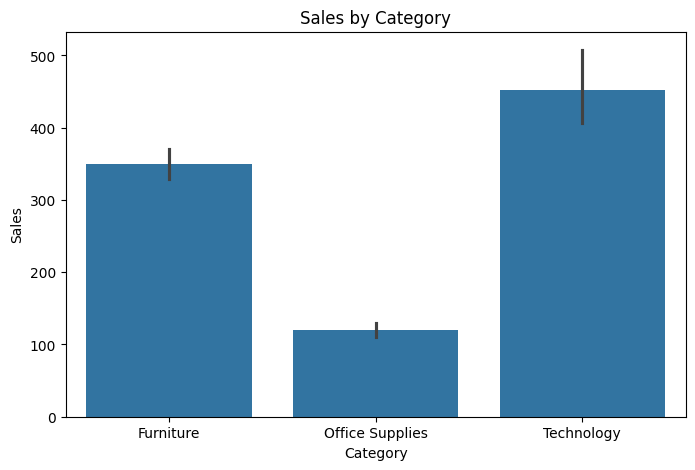

In [7]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Category',
    y='Sales',
    data=df
)

plt.title("Sales by Category")
plt.show()

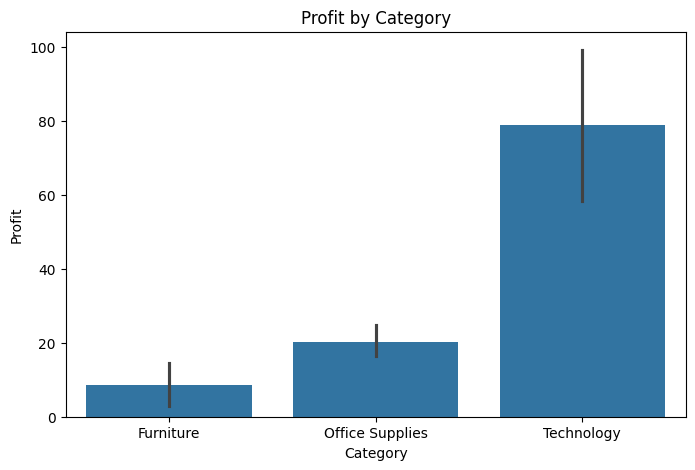

In [8]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Category',
    y='Profit',
    data=df
)

plt.title("Profit by Category")
plt.show()

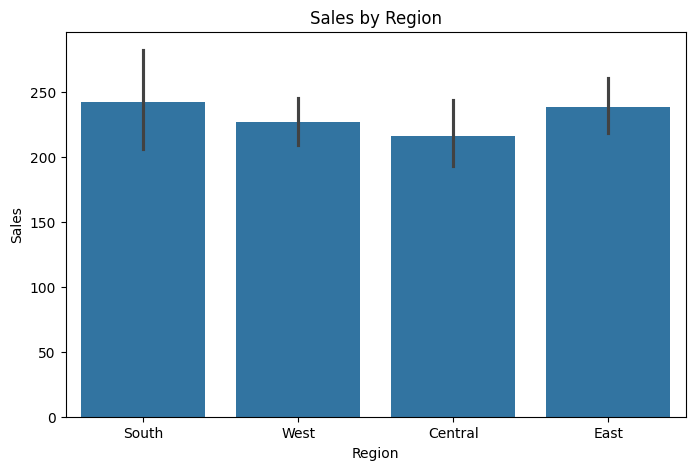

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Region',
    y='Sales',
    data=df
)

plt.title("Sales by Region")
plt.show()

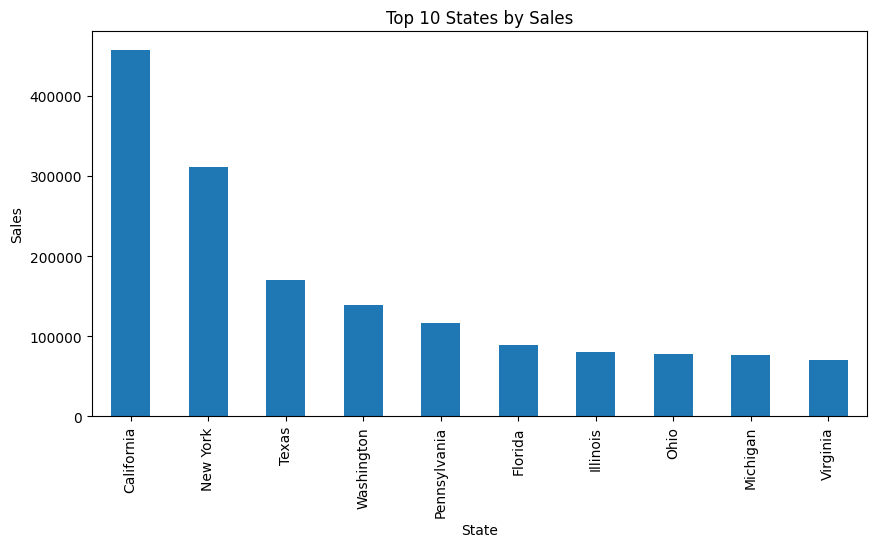

In [10]:
top_states = df.groupby('State')['Sales'].sum()

top_states = top_states.sort_values(
    ascending=False
).head(10)

top_states.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 States by Sales")
plt.ylabel("Sales")
plt.show()

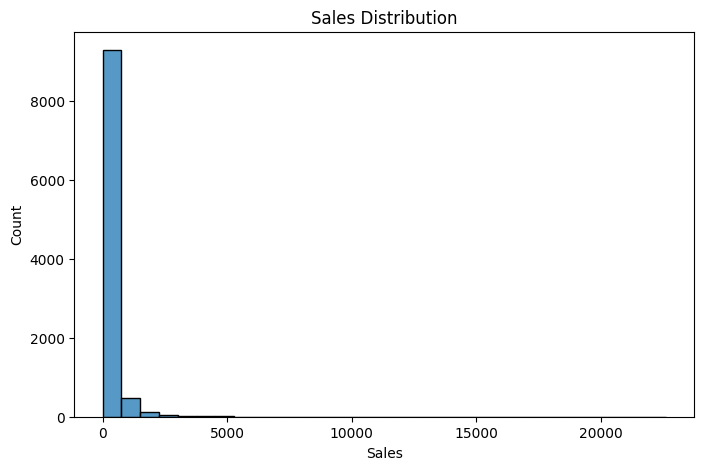

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Sales'],
    bins=30
)

plt.title("Sales Distribution")
plt.show()

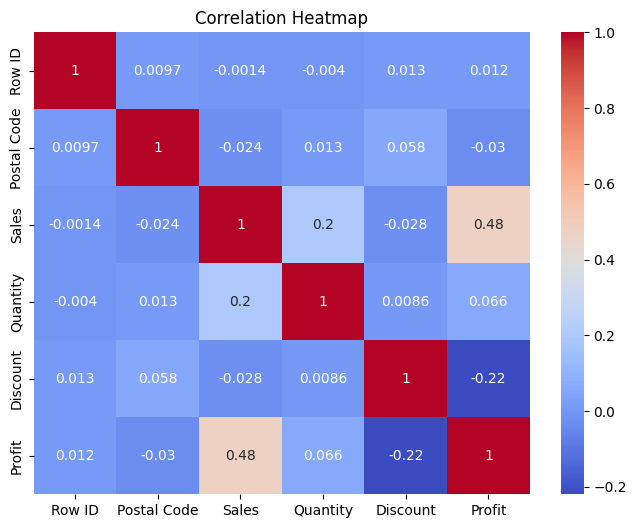

In [12]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [14]:
X = df[['Quantity', 'Discount', 'Profit']]

y = df['Sales']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("MAE =", mean_absolute_error(y_test, y_pred))

print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score =", r2_score(y_test, y_pred))

MAE = 245.0755698445027
RMSE = 824.8499599151105
R2 Score = -0.15181720106063934


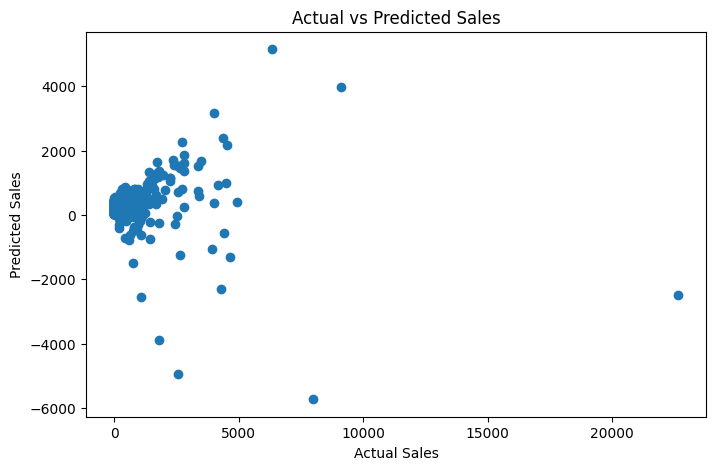

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

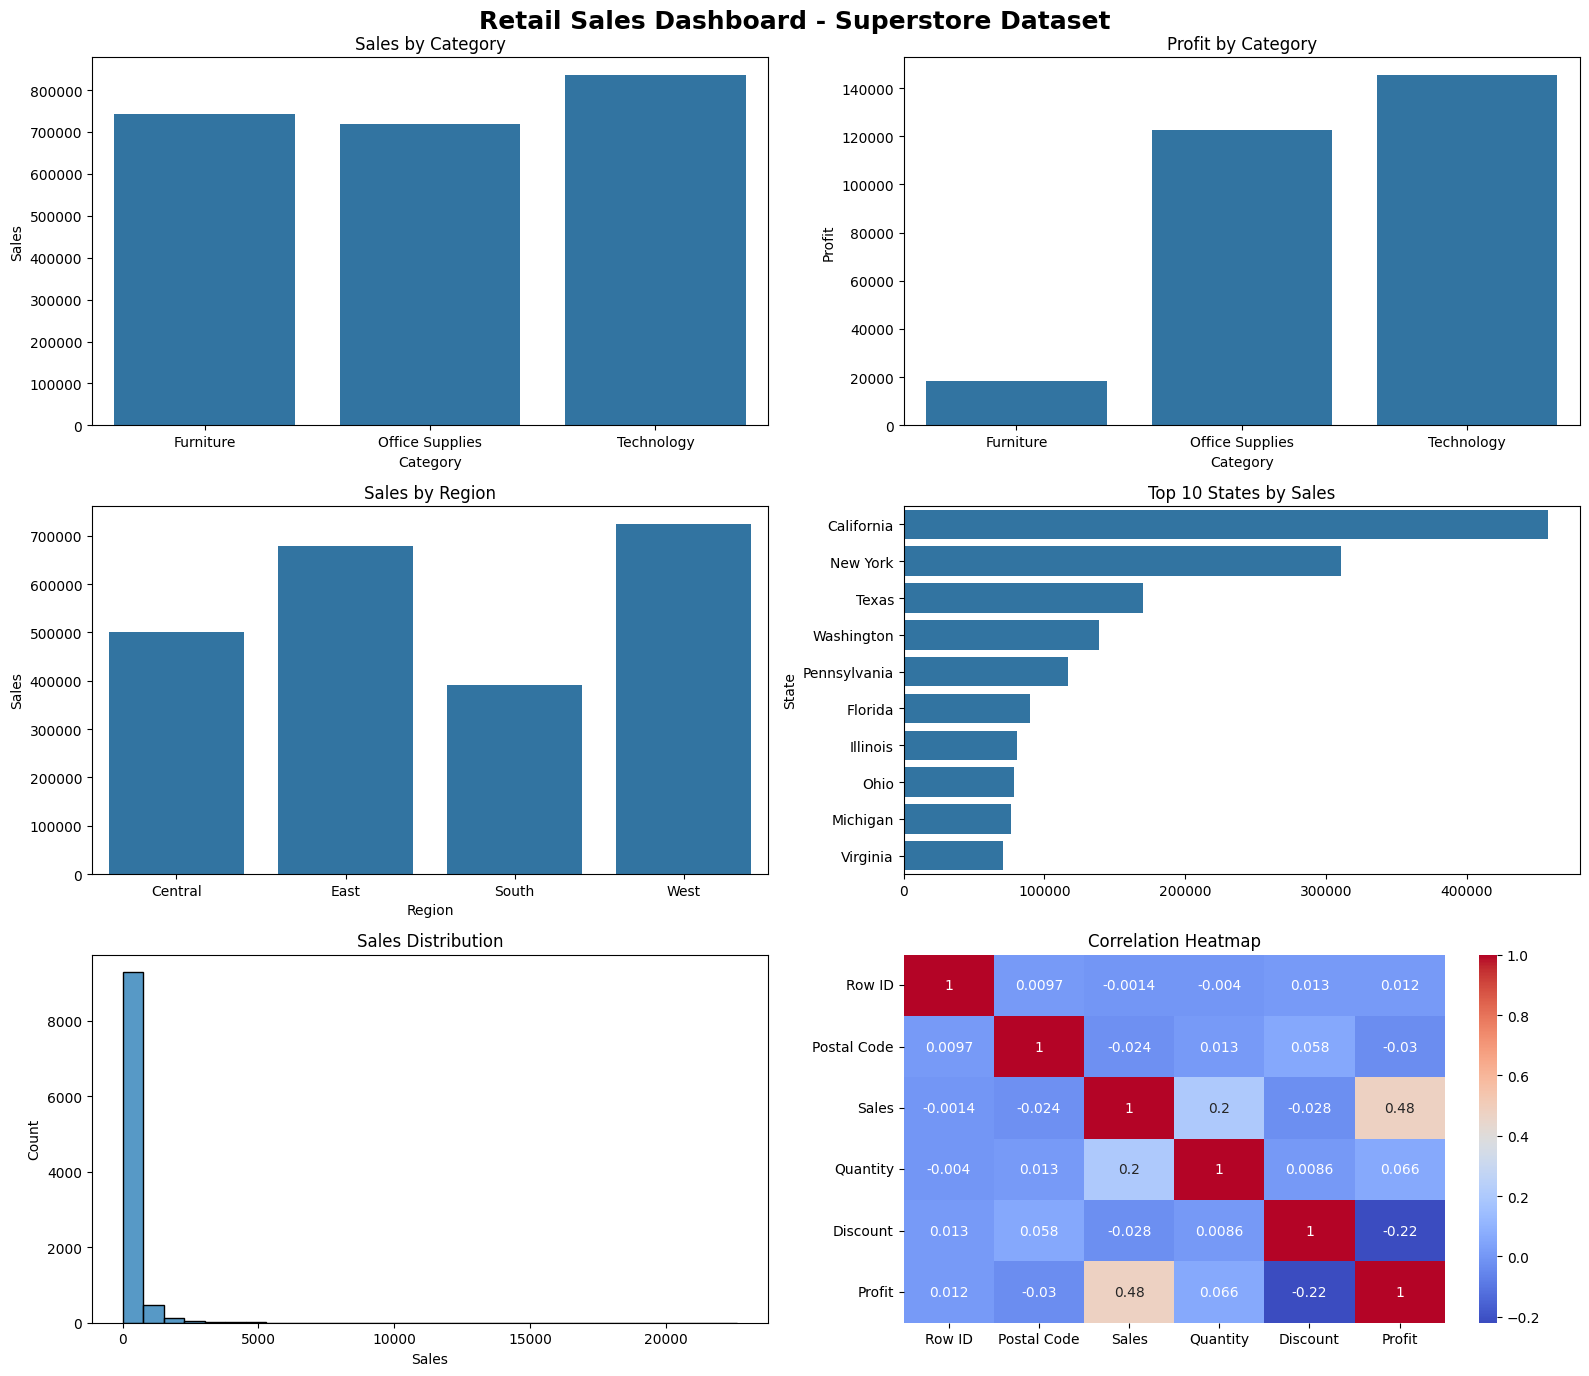

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv(r"C:\Users\Tejas\Desktop\Tejas\Data Science Intern Tasks\Sample - Superstore.csv", encoding="latin1")

# Dashboard Layout
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# 1. Sales by Category
sales_cat = df.groupby('Category')['Sales'].sum().reset_index()
sns.barplot(data=sales_cat, x='Category', y='Sales', ax=axes[0,0])
axes[0,0].set_title("Sales by Category")

# 2. Profit by Category
profit_cat = df.groupby('Category')['Profit'].sum().reset_index()
sns.barplot(data=profit_cat, x='Category', y='Profit', ax=axes[0,1])
axes[0,1].set_title("Profit by Category")

# 3. Sales by Region
sales_region = df.groupby('Region')['Sales'].sum().reset_index()
sns.barplot(data=sales_region, x='Region', y='Sales', ax=axes[1,0])
axes[1,0].set_title("Sales by Region")

# 4. Top 10 States by Sales
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

sns.barplot(
    x=top_states.values,
    y=top_states.index,
    ax=axes[1,1]
)
axes[1,1].set_title("Top 10 States by Sales")

# 5. Sales Distribution
sns.histplot(df['Sales'], bins=30, ax=axes[2,0])
axes[2,0].set_title("Sales Distribution")

# 6. Correlation Heatmap
numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    ax=axes[2,1]
)
axes[2,1].set_title("Correlation Heatmap")

# Dashboard Title
plt.suptitle(
    "Retail Sales Dashboard - Superstore Dataset",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.show()